# The "Last Mile" Logistics Auditor

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import requests

## Datasets

In [72]:
orders = pd.read_csv("olist_orders_dataset.csv", encoding="latin1")
customers = pd.read_csv("olist_customers_dataset.csv", encoding="latin1")
reviews = pd.read_csv("olist_order_reviews_dataset.csv", encoding="latin1")
items = pd.read_csv("olist_order_items_dataset.csv", encoding="latin1")
products = pd.read_csv("olist_products_dataset.csv", encoding="latin1")
translation = pd.read_csv("product_category_name_translation.csv", encoding="latin1")

### Explaratory Data Analysis

In [73]:
datasets = {
    "orders": orders,
    "reviews": reviews,
    "customers": customers,
    "products": products
}

for name, df in datasets.items():
    print("\n")
    print(name.upper())
    print("*"*70)
    print("Shape:", df.shape)
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nData types:")
    print(df.dtypes)



ORDERS
**********************************************************************
Shape: (99441, 8)

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicate rows: 0

Data types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


REVIEWS
**********************************************************************
Shape: (99224, 7)

Missing values:
review_id                      0
order_id                       0
review_score        

# Story 1. The Schema Builder

In [74]:
orders = pd.read_csv("olist_orders_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")

**Join** _ Master datasets

In [75]:
print("Orders rows before join:", orders.shape[0])

master = orders.merge(customers, on="customer_id", how="left")

print("Rows after joining customers and orders:", master.shape[0])

review_scores = reviews[["order_id", "review_score"]]
master = master.merge(review_scores, on="order_id", how="left")

print("Rows after joining reviews:", master.shape[0])

print("Unique orders:", master["order_id"].nunique())
print("Total rows:", master.shape[0])
print("Duplicated order_id:", master["order_id"].duplicated().sum())

master.head()

Orders rows before join: 99441
Rows after joining customers and orders: 99441
Rows after joining reviews: 99992
Unique orders: 99441
Total rows: 99992
Duplicated order_id: 551


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,5.0


Some orders have more than one review.  Keeping one review score per order

In [76]:

reviews_clean = (reviews.sort_values("review_answer_timestamp").drop_duplicates(subset="order_id", keep="last")[["order_id", "review_score"]]
)

master = orders.merge(customers, on="customer_id", how="left")

master = master.merge(reviews_clean, on="order_id", how="left")

print("Orders rows before join:", orders.shape[0])
print("Rows after joining customers and reviews:", master.shape[0])
print("Unique orders:", master["order_id"].nunique())
print("Duplicated order_id:", master["order_id"].duplicated().sum())

master.head()

Orders rows before join: 99441
Rows after joining customers and reviews: 99441
Unique orders: 99441
Duplicated order_id: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,5.0


# Story 2. The "Real" Delay Calculator



In [77]:
master["order_delivered_customer_date"] = pd.to_datetime(master["order_delivered_customer_date"])
master["order_estimated_delivery_date"] = pd.to_datetime(master["order_estimated_delivery_date"])

not_delivered = master[master["order_delivered_customer_date"].isna()].copy()
delivered = master[master["order_delivered_customer_date"].notna()].copy()

delivered["Days_Difference"] = (
    delivered["order_estimated_delivery_date"] -
    delivered["order_delivered_customer_date"]
).dt.days

def classify_delivery(days):
    if days >= 0:
        return "On Time"
    elif days < -5:
        return "Super Late"
    else:
        return "Late"

delivered["Delivery_Status"] = delivered["Days_Difference"].apply(classify_delivery)

print("Delivered orders:", delivered.shape[0])
print("Not delivered orders:", not_delivered.shape[0])
print(delivered["Delivery_Status"].value_counts())

Delivered orders: 96476
Not delivered orders: 2965
Delivery_Status
On Time       88649
Super Late     4212
Late           3615
Name: count, dtype: int64


* Flagged

In [78]:
not_delivered = master[master["order_delivered_customer_date"].isna()]

not_delivered[["order_id", "customer_id", "order_status",
               "order_purchase_timestamp",
               "order_delivered_customer_date"]].head()

not_delivered["order_status"].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


#  Story 3. The bar chart




In [79]:
state_performance = delivered.groupby("customer_state").agg(Total_Orders=("order_id","count"), Late_Orders=("Delivery_Status", lambda x: (x != "On Time").sum())).reset_index()

state_performance["Late_Percentage"] = (state_performance["Late_Orders"] / state_performance["Total_Orders"] * 100).round(2)

state_performance.sort_values("Late_Percentage", ascending=False).head(10)

,customer_state,Total_Orders,Late_Orders,Late_Percentage
1,AL,397,95,23.93
9,MA,717,141,19.67
16,PI,476,76,15.97
5,CE,1279,196,15.32
24,SE,335,51,15.22
4,BA,3256,457,14.04
18,RJ,12353,1664,13.47
26,TO,274,35,12.77
13,PA,946,117,12.37
7,ES,1995,244,12.23


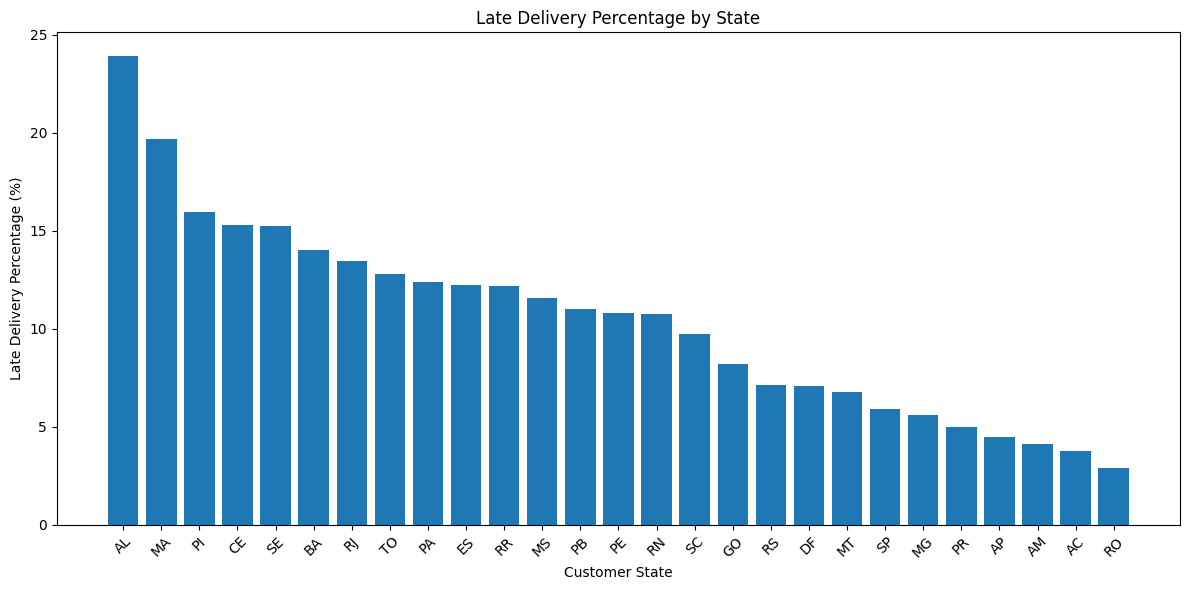

In [80]:
all_states = state_performance.sort_values(
    "Late_Percentage", ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    all_states["customer_state"],
    all_states["Late_Percentage"]
)

plt.xlabel("Customer State")
plt.ylabel("Late Delivery Percentage (%)")
plt.title("Late Delivery Percentage by State")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Insight:

* The highest late delivery rate is in AL, where 95 out of 397 delivered orders were late, giving a late rate of 23.93%. Other high-delay states are mostly in the North and Northeast, including MA with 141 late orders out of 717 orders (19.67%), PI with 76 out of 476 (15.97%), CE with 196 out of 1,279 (15.32%), SE with 51 out of 335 (15.22%), BA with 457 out of 3,256 (14.04%), TO with 35 out of 274 (12.77%), and PA with 117 out of 946 (12.37%). This suggests that remote or less central regions are disproportionately affected by late deliveries. However, RJ also appears in the top 10 with 1,664 late orders out of 12,353 orders (13.47%), showing that the issue is not only limited to remote states.

# Story 4.  The Sentiment Correlation

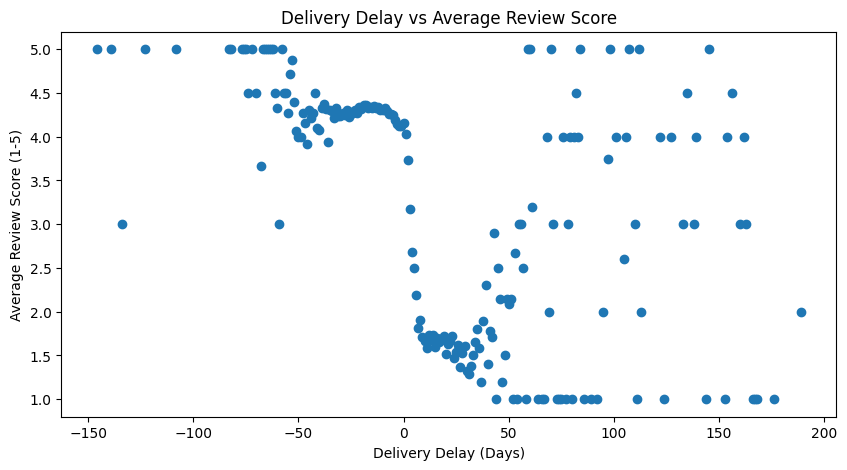

In [81]:
sentiment_data = delivered.dropna(subset=["review_score"]).copy()

sentiment_data["Delivery_Delay_Days"] = -sentiment_data["Days_Difference"]

delay_review = (
    sentiment_data
    .groupby("Delivery_Delay_Days")["review_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.scatter(delay_review["Delivery_Delay_Days"], delay_review["review_score"])

plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Average Review Score (1-5)")
plt.title("Delivery Delay vs Average Review Score")

plt.show()

In [82]:
sentiment_summary = sentiment_data.groupby("Delivery_Status")["review_score"].mean().reset_index()

sentiment_summary

,Delivery_Status,review_score
0,Late,3.460482
1,On Time,4.293973
2,Super Late,1.784807


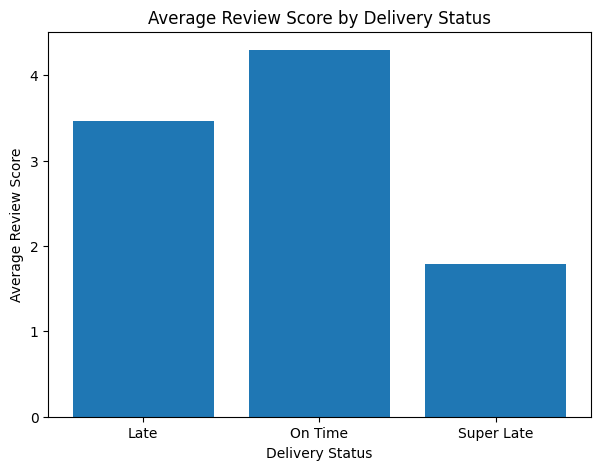

In [83]:
plt.figure(figsize=(7,5))
plt.bar(sentiment_summary["Delivery_Status"], sentiment_summary["review_score"])
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.title("Average Review Score by Delivery Status")
plt.show()

#Story 5. Product Category Translation

In [84]:
order_items = pd.read_csv("olist_order_items_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

product_data = order_items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")

product_data = product_data.merge(translation, on="product_category_name", how="left")

product_data[["order_id", "product_category_name_english"]].head()

,order_id,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools


In [85]:
category_delivery = delivered.merge(product_data[["order_id", "product_category_name_english"]], on="order_id", how="left")

category_performance = category_delivery.dropna(subset=["product_category_name_english"]).groupby("product_category_name_english").agg(
    Total_Orders=("order_id", "count"),
    Late_Orders=("Delivery_Status", lambda x: (x != "On Time").sum()),
    Avg_Review=("review_score", "mean")
).reset_index()

category_performance["Late_Percentage"] = (category_performance["Late_Orders"] / category_performance["Total_Orders"] * 100).round(2)

category_performance.sort_values("Late_Percentage", ascending=False).head(10)

,product_category_name_english,Total_Orders,Late_Orders,Avg_Review,Late_Percentage
46,home_comfort_2,30,5,3.629630,16.67
41,furniture_mattress_and_upholstery,37,5,3.891892,13.51
4,audio,362,46,3.837989,12.71
33,fashion_underwear_beach,127,16,4.047619,12.60
12,christmas_supplies,150,18,4.069930,12.00
10,books_technical,263,29,4.389313,11.03
47,home_confort,429,44,3.852459,10.26
18,construction_tools_lights,301,30,4.082192,9.97
36,food,499,49,4.262834,9.82
26,electronics,2729,266,4.067159,9.75


Home_comfort_2 had the highest late rate at 16.67%, but it had only 30 orders, so the result is less stable. Among larger categories, audio had 12.71% late deliveries, home_confort 10.26%, food 9.82%, and electronics 9.75%. This suggests some product categories may be harder to deliver reliably, especially bulky or high-volume items.

# 6. The "Candidate's Choice" Challenge

Delivery Performance by Month

In [86]:
delivered["order_purchase_timestamp"] = pd.to_datetime(delivered["order_purchase_timestamp"])

delivered["Month_Num"] = delivered["order_purchase_timestamp"].dt.month
delivered["Month"] = delivered["order_purchase_timestamp"].dt.month_name()

monthly_performance = delivered.groupby(["Month_Num", "Month"]).agg(
    Total_Orders=("order_id", "count"),
    Late_Orders=("Delivery_Status", lambda x: (x != "On Time").sum())
).reset_index()

monthly_performance["Late_Percentage"] = (
    monthly_performance["Late_Orders"] / monthly_performance["Total_Orders"] * 100
).round(2)

monthly_performance = monthly_performance.sort_values("Month_Num")

monthly_performance[["Month", "Total_Orders", "Late_Orders", "Late_Percentage"]]

,Month,Total_Orders,Late_Orders,Late_Percentage
0,January,7819,487,6.23
1,February,8209,1102,13.42
2,March,9549,1638,17.15
3,April,9101,542,5.96
4,May,10294,684,6.64
5,June,9231,204,2.21
6,July,10028,409,4.08
7,August,10544,799,7.58
8,September,4151,217,5.23
9,October,4748,240,5.05


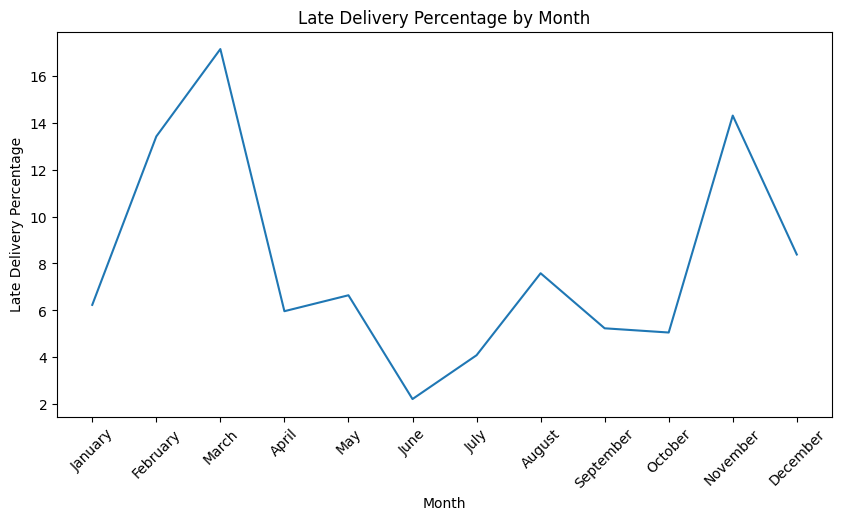

In [87]:
plt.figure(figsize=(10,5))
plt.plot(monthly_performance["Month"], monthly_performance["Late_Percentage"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Late Delivery Percentage")
plt.title("Late Delivery Percentage by Month")
plt.show()

I added a monthly late delivery analysis to see which months had more delays. The results show that March had the highest late delivery rate at **17.2%**, followed by November at **14.3%** and February at **13.4%**, while June had the lowest rate at **2.2%**. This helps Veridi Logistics prepare earlier for risky months by adding more delivery support before delays affect customer satisfaction.



Saving datasets

In [88]:
delivered.to_csv("delivered.csv", index=False)
state_performance.to_csv("state_performance.csv", index=False)
category_performance.to_csv("category_performance.csv", index=False)
monthly_performance.to_csv("monthly_performance.csv", index=False)
master.to_csv("master.csv", index=False)
delay_review.to_csv("delay_review.csv", index=False)